----
----
#  EXPLANATION NOTEBOOK:   

In this notebook we will Detail the workflow of our algorithm (main.py)
----
----
----

## IMPORT


In [1]:
from src.model_initialization import load_yolo_model, load_posenet_model, load_depth_estimation_model
from src.calibration import process_and_plot_calibration
from src.depth_estimation import estimate_depth
from src.direction_speed import calculate_direction, calculate_speed
from src.cost_map import animate_cost_map, simulation, create_internal_obstacles
from src.draw_boxes import detect_persons
from src.navigation_algo import simulate_robot_navigation
from src.utils import preprocess_boxes, calculate_pixel_value, horizontal_pixel_pos, horizontal_pos_conversion, predict_distance, get_image_size, resize_to_x_by_x, create_internal_obstacles

In [11]:
import numpy as np

#dynamic_obstacles_pos = np.array([[200, 250]])
#dynamic_obstalcles_dir_speed = [(2.2*np.pi/2, 1)]


Step 0:
  - Length of robot_positions: 2
  - Length of cost_map_times: 2
  - Length of dynamic_obstacles_times: 2
Step 1:
  - Length of robot_positions: 3
  - Length of cost_map_times: 3
  - Length of dynamic_obstacles_times: 3
Step 2:
  - Length of robot_positions: 4
  - Length of cost_map_times: 4
  - Length of dynamic_obstacles_times: 4
Step 3:
  - Length of robot_positions: 5
  - Length of cost_map_times: 5
  - Length of dynamic_obstacles_times: 5
Step 4:
  - Length of robot_positions: 6
  - Length of cost_map_times: 6
  - Length of dynamic_obstacles_times: 6
Step 5:
  - Length of robot_positions: 7
  - Length of cost_map_times: 7
  - Length of dynamic_obstacles_times: 7
Step 6:
  - Length of robot_positions: 8
  - Length of cost_map_times: 8
  - Length of dynamic_obstacles_times: 8
Step 7:
  - Length of robot_positions: 9
  - Length of cost_map_times: 9
  - Length of dynamic_obstacles_times: 9
Step 8:
  - Length of robot_positions: 10
  - Length of cost_map_times: 10
  - Length of

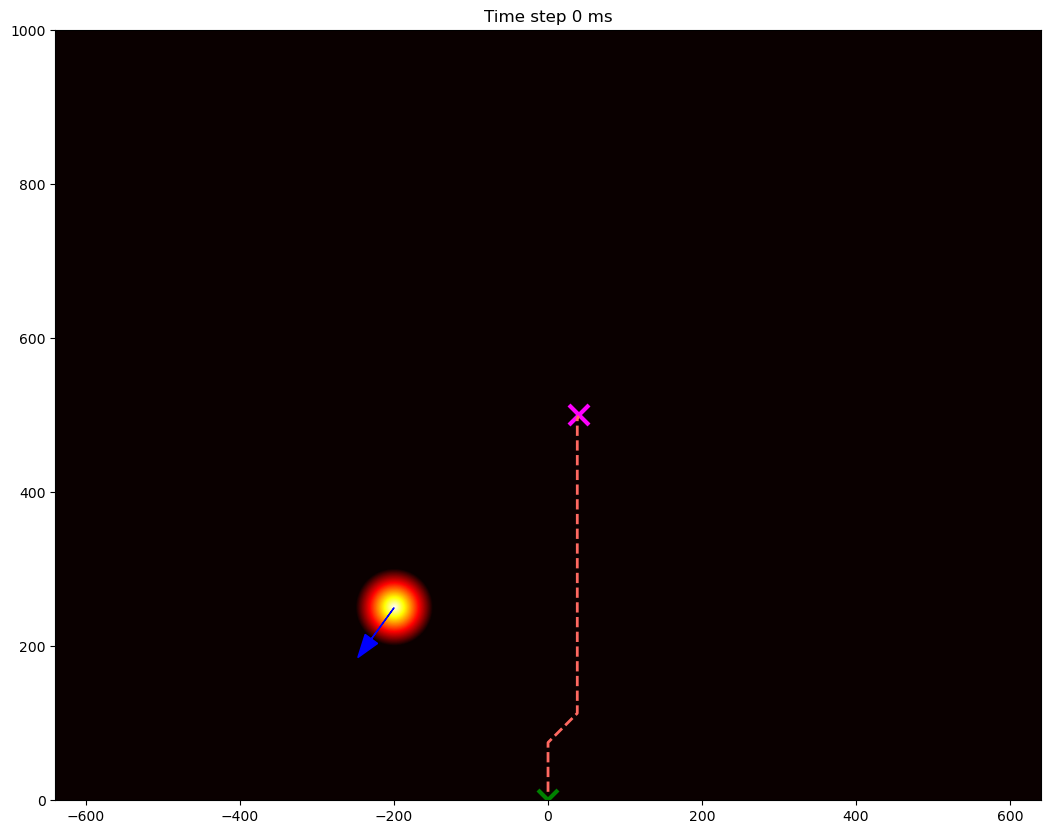

In [12]:
# Define the number of internal obstacles
num_internal_obstacles = 20

# Define the grid size
grid_size = (1280, 1000)

# Create the initial obstacles inside the grid
dynamic_obstacles_pos, dynamic_obstalcles_dir_speed = create_internal_obstacles(num_internal_obstacles)

start_position = (0, 0)
goal_position = (40, 400)

# Define the robot's speed
robot_speed = 1.1  

# Define the number of time steps and time increment
simulation_time = 10000     # time of simulation in ms 
dt = 100                    # time btw frame in ms

# Run the simulation
robot_positions, cost_maps, dynamic_obstacles_times, path_times= simulation(
    dynamic_obstacles_pos, 
    dynamic_obstalcles_dir_speed, 
    start_position, 
    goal_position, 
    robot_speed, 
    simulation_time,
    dt
)

# Animate the simulation results
anim = animate_cost_map(cost_maps, robot_positions, dynamic_obstacles_times, dynamic_obstalcles_dir_speed, goal_position, simulation_time, dt, path_times)

# Display the animation
from IPython.display import HTML
HTML(anim.to_jshtml())


In [4]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, writers

# Set up the writer for saving as MP4
Writer = writers['ffmpeg']
writer = Writer(fps=15, metadata=dict(artist='Me'), bitrate=1800)

# Save the animation as an MP4 file
anim.save('/Users/paulrichard/Documents/HAAN/animation2.mp4', writer=writer)

----
----
## Models initialisation: 


In [5]:
yolo_model = load_yolo_model()
posenet_model = load_posenet_model()
depth_processor, depth_model = load_depth_estimation_model()

Using cache found in /Users/paulrichard/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2024-8-13 Python-3.8.18 torch-2.0.1 CPU

Fusing layers... 
YOLOv5n summary: 213 layers, 1867405 parameters, 0 gradients
Adding AutoShape... 


YOLOv5 model loaded successfully.
MoveNet (PoseNet) model loaded successfully.



----
----
## Calibration:

Here is the method we used to find best fitting curve

In [ ]:
%matplotlib inline

input_folder = '/Users/prichard/miniconda3/envs/infosys/cv_project/data/input/calibration/normal_size'
output_folder = '/Users/prichard/miniconda3/envs/infosys/cv_project/data/output'
#best_model, prediction_param = process_and_plot_calibration(input_folder, yolo_model, depth_processor, depth_model, output_folder)
best_model = "Polynomial"
prediction_param = (0.00029224, -0.10041, 8.3828)

Small image error = 0.2629 \
Medium image error = 0.2126 \
High image error = 0.2082 \
Normal image error = 0.1980


![Curve Data](images/Curve_Data_Big1_512.png)
![Curve Data](images/Curve_Data_Big1_1024.png)
![Curve Data](images/Curve_Data_Big1_2048.png)
![Curve Data](images/Curve_Data_Big1_3000.png)


Person detection complete. Found 2 persons.
Direction estimation complete


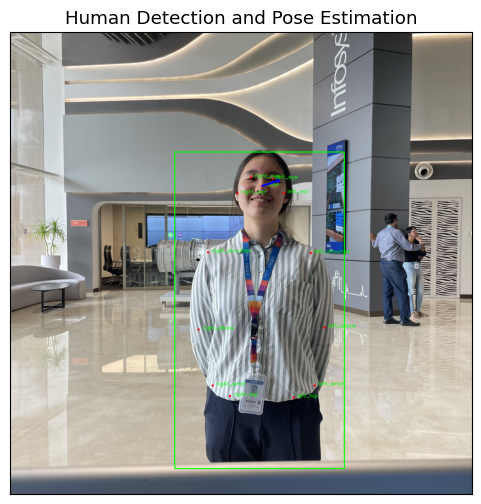

In [ ]:
test_image_path = "data/input/calibration/high_size/0.9.jpeg"
DISP = True

robot_speed = 1.11 #  [m/s]

new_size = (1280, 1280)

img, size_img = get_image_size(test_image_path)

resized_image = resize_to_x_by_x(img, new_size)

depth_image = estimate_depth(resized_image, depth_processor, depth_model) # 0.5
coords_box_in_pixel = detect_persons(resized_image, yolo_model) # traduire dans la nouvelle map et pour l'instant mettre tout en cm avec juste pixel = 0.1 cm

filtered_depth_images = preprocess_boxes(depth_image, coords_box_in_pixel)
pixel_values = calculate_pixel_value(filtered_depth_images)

horizontal_pos_in_pixel = horizontal_pixel_pos(coords_box_in_pixel)
horizontal_pos_in_cm = horizontal_pos_conversion(horizontal_pos_in_pixel) # here we change the coordinates st the 0,0 is the robot position 

depth_values = [predict_distance(pv, prediction_param, best_model.lower()) for pv in pixel_values]

directions = calculate_direction(resized_image, coords_box_in_pixel, depth_values, posenet_model, DISP)
speeds = calculate_speed(resized_image, coords_box_in_pixel)


# Define parameters
num_internal_obstacles = 10
num_entry_obstacles = 30
grid_size = (1280, 1000)  # Grid dimensions (width, height)
entry_speed = 1  # Speed of obstacles entering the grid (cm/s)
time_steps = 100
dt = 10

GOAL = (10, 50)

# Create obstacles already inside the grid
internal_obstacles = create_internal_obstacles(num_internal_obstacles, grid_size, time_steps, dt)

# Create obstacles entering from the edges
entry_obstacles = create_entry_obstacles(num_entry_obstacles, grid_size, entry_speed, time_steps, dt)

# Combine both internal and entry obstacles
dynamic_obstacles = internal_obstacles + entry_obstacles

cost_map = create_time_dependent_cost_map(dynamic_obstacles, time_steps)


In [ ]:
num_internal_obstacles = 2
num_entry_obstacles = 10
grid_size = (1280, 1000)  # Grid dimensions (width, height)
entry_speed = 1  # Speed of obstacles entering the grid (cm/s)

# Create obstacles already inside the grid
dynamic_obstacles_pos, dynamic_obstalcles_dir_speed = create_internal_obstacles(num_internal_obstacles)

print(dynamic_obstacles_pos)
print(dynamic_obstalcles_dir_speed)

[[    -429.53      221.88]
 [     268.47       154.7]]
[(1.753037560444917, 0.9665823474291293), (2.556002405989773, 0.7308506368091948)]


In [ ]:
start_position = (0, 0)
goal_position = (150, 80)
robot_speed = 1.1  
time_steps = 50
dt = 2

# Run the simulation
robot_positions, cost_maps, dynamic_obstacles_projection = simulation(dynamic_obstacles_pos, dynamic_obstalcles_dir_speed, start_position, goal_position, robot_speed, time_steps, dt)


start (0, 0)
x,y 0 0
x,y 639 1
x,y 639 0
x,y 640 1
x,y 641 1
x,y 641 0
x,y 1278 2
x,y 1278 1
x,y 1278 0
x,y 1278 0
x,y 1279 2
x,y 1279 1
x,y 1279 0


ValueError: too many values to unpack (expected 3)

In [ ]:
print(len(dynamic_obstacles_projection))


26


In [ ]:
# Animate the results
anim = animate_cost_map(cost_maps, robot_positions, dynamic_obstacles_projection, goal_position, time_steps, dt, interval=20)

# Display the animation in a Jupyter notebook
from IPython.display import HTML
HTML(anim.to_jshtml())

TypeError: animate_cost_map() got an unexpected keyword argument 'interval'

A Faire Demain: Prendre les nouvelles image avec le truc à 1 m \
recomparer les erreurs\
faire une matrice pour representer la map \
mettre en proba et essayer de plot 


In [ ]:
dynamic_obstacles = [((100, 100), 0, 1)]

dynamic_obstacles = create_dynamic_obstacles(depth_values, horizontal_pos_in_cm, directions, speeds, time_steps=100, dt=10)


from IPython.display import HTML 
# To display the animation in a Jupyter notebook:
anim = animate_cost_map(cost_map, dynamic_obstacles, GOAL, time_steps=100, dt=10, interval=100)
anim  = animate_cost_map(cost_map, dynamic_obstacles, GOAL, robot_speed, time_steps=100, dt=10, interval=100)
HTML(anim.to_jshtml())

In [ ]:
import numpy as np

matrix = np.zeros((10,1,4))

x= 2
y =2 
dir = 0
speed = 1

matrix[0,0,:]= [x,y, dir, speed]

matrix[1,0]


array([          0,           0,           0,           0])

In [ ]:
# Simulation parameters
num_internal_obstacles = 2
num_entry_obstacles = 10  # If you have entry obstacles
grid_size = (1280, 1000)  # Grid dimensions (width, height)
entry_speed = 1  # Speed of obstacles entering the grid (cm/s)

# Robot and simulation settings
start_position = (0, 0)
goal_position = (150, 80)
robot_speed = 1.1  
time_steps = 50
dt = 2

In [ ]:
# Create obstacles already inside the grid
dynamic_obstacles_pos, dynamic_obstalcles_dir_speed = create_internal_obstacles(num_internal_obstacles)

# Print initial obstacle positions and their directions/speeds
print(dynamic_obstacles_pos)
print(dynamic_obstalcles_dir_speed)

[[    -35.627      536.24]
 [    -107.22      339.03]]
[(3.0169860986580406, 1.078047623167142), (4.450619523303786, 0.6736282057411327)]


In [ ]:
# Run the simulation
robot_positions, cost_maps, dynamic_obstacles_projection = simulation(
    dynamic_obstacles_pos, 
    dynamic_obstalcles_dir_speed, 
    start_position, 
    goal_position, 
    robot_speed, 
    time_steps, 
    dt
)

# Check the length of dynamic obstacles projection
print(len(dynamic_obstacles_projection))

25


In [ ]:
import numpy as np

two_array = np.zeros((3,3))
list = []

print ('matrice 0 :')
print(two_array)

list.append(two_array)
two_array1=two_array.copy()
two_array1[:,1] = 1
print ('matrice 1')
print(two_array1)

print ("---")

list.append(two_array1)
list[1][1][1]


matrice 0 :
[[          0           0           0]
 [          0           0           0]
 [          0           0           0]]
matrice 1
[[          0           1           0]
 [          0           1           0]
 [          0           1           0]]
---


1.0

In [ ]:
# Define the number of internal obstacles
num_internal_obstacles = 2

# Define the grid size
grid_size = (1280, 1000)

# Create the initial obstacles inside the grid
dynamic_obstacles_pos, dynamic_obstalcles_dir_speed = create_internal_obstacles(num_internal_obstacles)

# Define the robot's start and goal positions
start_position = (0, 0)
goal_position = (-540, 690)

# Define the robot's speed
robot_speed = 1.1  

# Define the number of time steps and time increment
simulation_time = 10000     #time of simulation in ms 
dt = 100                    # time btw frame in ms

scale = 10

# Run the simulation
robot_positions, cost_maps, dynamic_obstacles_times, path_times= simulation(
    dynamic_obstacles_pos, 
    dynamic_obstalcles_dir_speed, 
    start_position, 
    goal_position, 
    robot_speed, 
    simulation_time, 
    dt,
    grid_size,
    scale
)

# Animate the simulation results
anim = animate_cost_map(cost_maps, robot_positions, dynamic_obstacles_times, dynamic_obstalcles_dir_speed, goal_position, simulation_time, dt, path_times, grid_size, scale)

# Display the animation
from IPython.display import HTML
HTML(anim.to_jshtml())